In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

df  = pd.read_parquet("../data/processed/features.parquet")
cfg = yaml.safe_load(open("../config.yaml"))

fv = df["future_vol_60s"].dropna()
print(f"{len(fv):,} labelled ticks")

110,790 labelled ticks


In [2]:
# --- percentile table ---
rows = []
for p in [50, 75, 80, 85, 90, 95, 99]:
    t    = fv.quantile(p / 100)
    rate = (fv > t).mean() * 100
    move = t * 60_000          # approx $ move on a $60k BTC (σ × price)
    rows.append({"percentile": f"p{p}", "σ_future": round(t, 6),
                 "spike_rate": f"{rate:.1f}%", "≈$_move_1σ": f"${move:.2f}"})

pd.DataFrame(rows).set_index("percentile")

,σ_future,spike_rate,≈$_move_1σ
percentile,,,
p50,0.000023,50.0%,$1.40
p75,0.000034,25.0%,$2.06
p80,0.000037,20.0%,$2.24
p85,0.000041,15.0%,$2.48
p90,0.000046,10.0%,$2.75
p95,0.000053,5.0%,$3.18
p99,0.000076,1.0%,$4.56


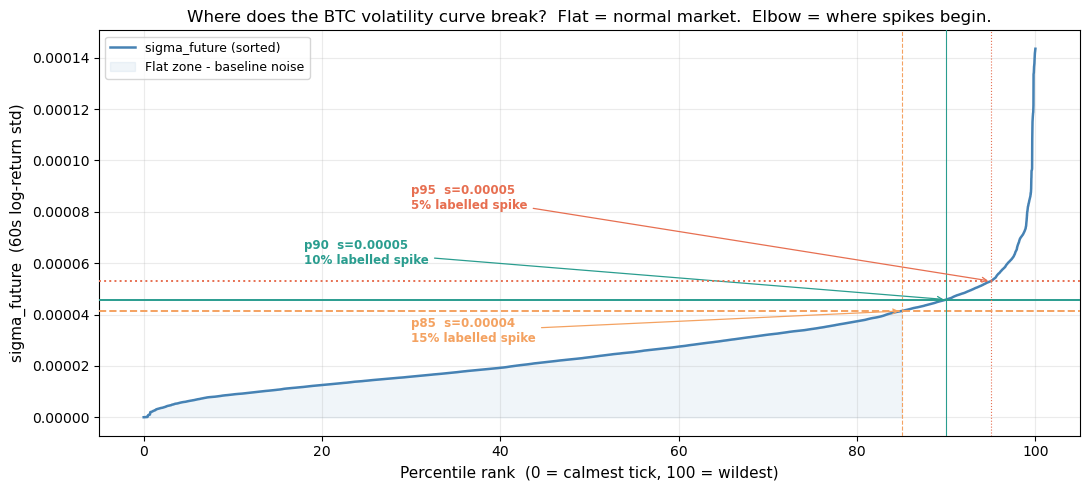

In [3]:
sorted_fv = np.sort(fv.values)
ranks     = np.linspace(0, 100, len(sorted_fv))

CANDIDATES    = {85: {"color": "#f4a261", "ls": "--"}, 90: {"color": "#2a9d8f", "ls": "-"}, 95: {"color": "#e76f51", "ls": ":"}}
LABEL_OFFSETS = {85: -0.000012, 90: 0.000014, 95: 0.000028}
LABEL_X       = {85: 30, 90: 18, 95: 30}

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ranks, sorted_fv, lw=1.8, color="steelblue", zorder=2, label="sigma_future (sorted)")
p85_val = fv.quantile(0.85)
ax.fill_between(ranks, sorted_fv, where=(sorted_fv <= p85_val), color="steelblue", alpha=0.08, label="Flat zone - baseline noise")

for p, style in CANDIDATES.items():
    val  = fv.quantile(p / 100)
    rate = (fv > val).mean() * 100
    ax.axhline(val, color=style["color"], lw=1.4, ls=style["ls"], zorder=3)
    ax.axvline(p,   color=style["color"], lw=0.8, ls=style["ls"], zorder=3)
    line1 = "p" + str(p) + "  s=" + format(val, ".5f")
    line2 = str(int(rate)) + "% labelled spike"
    ax.annotate(line1 + chr(10) + line2, xy=(p, val),
                xytext=(LABEL_X[p], val + LABEL_OFFSETS[p]),
                fontsize=8.5, color=style["color"], fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=style["color"], lw=0.9))

ax.set_xlabel("Percentile rank  (0 = calmest tick, 100 = wildest)", fontsize=11)
ax.set_ylabel("sigma_future  (60s log-return std)", fontsize=11)
ax.set_title("Where does the BTC volatility curve break?  Flat = normal market.  Elbow = where spikes begin.", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.5f"))
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("../reports/eda_percentile_plot.png", dpi=150)
plt.show()


I chose **τ = 0.000046** because it represents approximately the **90th percentile** of `future_vol_60s`
across the total dataset. At this threshold, roughly 10% of ticks are labelled as volatility spikes.